# Dynamiqs solver benchmark suite

This notebook is an interactive dashboard for the benchmark suite in `benchmarks/dynamiqs_benchmarks`.
It is intended for local solver exploration, reproducible benchmark logs, and long-term regression tracking.

The notebook can run every benchmark case created in the suite and then produce accuracy/speed visualizations:

- solver leaderboard tables,
- runtime vs relative-error scatter plots,
- benchmark × solver heatmaps for runtime and error,
- per-benchmark Pareto frontiers that show accuracy/speed tradeoffs,
- skipped/failed solver diagnostics.

## Dynamiqs benchmark design notes

The suite follows the solver structure exposed by Dynamiqs:

- `dq.sesolve(H, psi0, tsave, ...)` for closed Schrödinger dynamics.
- `dq.mesolve(H, jump_ops, rho0, tsave, ...)` for Lindblad/master-equation dynamics.
- Deterministic methods from `dynamiqs.method`: `Tsit5`, `Dopri5`, `Dopri8`, `Kvaerno3`, `Kvaerno5`, `Euler`, `Rouchon1`, `Rouchon2`, `Rouchon3`, and `Expm`.
- Time-dependent operators through `dq.modulated(...)` and `dq.pwc(...)`, matching driven and piecewise-constant benchmark cases.
- Solver diagnostics through `result.infos`, from which the runner extracts step counts and accepted/rejected steps when available.

Reference strategies are case-specific: analytical observable references (if available), `Expm` for feasible constant Liouvillians, or using tight double-precision for high-order ODE/Rouchon.

In [1]:
!git clone -b benchmark https://github.com/kwyip/dynamiqs
!pip install jax
%cd dynamiqs
!pip install -e ".[dev]"

Cloning into 'dynamiqs'...
remote: Enumerating objects: 9880, done.
remote: Counting objects: 100% (298/298), done.
remote: Compressing objects: 100% (211/211), done.
remote: Total 9880 (delta 194), reused 98 (delta 87), pack-reused 9582 (from 3)
Receiving objects: 100% (9880/9880), 4.65 MiB | 11.37 MiB/s, done.
Resolving deltas: 100% (7018/7018), done.
/content/dynamiqs
Obtaining file:///content/dynamiqs
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 4.8 MB/s eta 0:00:00
  Using cached flit_core-3.12.0-py3-none-any.whl.metadata (888 bytes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!ls

benchmark_example  docs      mkdocs.yml      pytest.ini      tests
benchmarks	   dynamiqs  NOTICE	     README.md
CONTRIBUTING.md    LICENSE   pyproject.toml  README_PYPI.md


In [3]:
%cd benchmark_example

/content/dynamiqs/benchmark_example


In [4]:
from __future__ import annotations

import csv
import math
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

# Make the notebook robust when opened from benchmark_example/ or repo root.
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = (
    NOTEBOOK_DIR if (NOTEBOOK_DIR / 'pyproject.toml').exists() else NOTEBOOK_DIR.parent
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from benchmarks.dynamiqs_benchmarks.cases import benchmark_cases
from benchmarks.dynamiqs_benchmarks.plot import plot_results
from benchmarks.dynamiqs_benchmarks.runner import parse_csv_list, run_suite

In [5]:
# --- Configuration ---------------------------------------------------------
# Use 'smoke' for a quick interactive pass, 'standard' for meaningful local
# comparisons, and 'full' for larger scaling runs.
PROFILE = 'smoke'
PRECISION = 'double'

# Set either value to a comma-separated string, e.g. 'Tsit5,Dopri8,Expm' or
# 'driven_damped_oscillator_mesolve'. Use None to run the default suite.
METHOD_FILTER = None
CASE_FILTER = None

# Timings exclude first-call JAX compilation when WARMUP=True.
WARMUP = True

OUTPUT_DIR = REPO_ROOT / 'benchmark_results' / f'notebook_{PROFILE}'
RESULTS_CSV = OUTPUT_DIR / 'results.csv'

In [6]:
def markdown_table(headers, rows):
    table = ['| ' + ' | '.join(headers) + ' |']
    table.append('| ' + ' | '.join(['---'] * len(headers)) + ' |')
    for row in rows:
        table.append('| ' + ' | '.join(str(item) for item in row) + ' |')
    return '\n'.join(table)


def load_results(path):
    with path.open() as f:
        rows = list(csv.DictReader(f))
    numeric_columns = {'runtime_s', 'nsteps', 'naccepted', 'nrejected', 'error'}
    for row in rows:
        for key in numeric_columns:
            try:
                row[key] = float(row[key])
            except (TypeError, ValueError):
                row[key] = math.nan
    return rows


def status_counts(rows):
    counts = defaultdict(int)
    for row in rows:
        counts[row['status']] += 1
    return dict(sorted(counts.items()))

In [7]:
case_rows = []
for case in benchmark_cases(PROFILE):
    case_rows.append(
        [f'`{case.name}`', case.kind, ', '.join(case.tags), case.reference_strategy]
    )

display(
    Markdown(
        markdown_table(['Benchmark', 'API', 'Tags', 'Reference strategy'], case_rows)
    )
)

| Benchmark | API | Tags | Reference strategy |
| --- | --- | --- | --- |
| `cross_resonance_modulated_sesolve` | sesolve | closed, two-qubit, time-dependent | Dopri8, double precision, rtol=atol=1e-10, safety_factor=0.75. |
| `driven_damped_oscillator_mesolve` | mesolve | open, one-mode, analytical-reference | Analytical oscillator amplitude <a>(t)=2 eps/kappa (1-exp(-kappa t/2)). |
| `batched_kerr_oscillator_mesolve` | mesolve | open, one-mode, batched, nonlinear | Expm for smoke/standard constant Liouvillian; tight Dopri8 is a fallback for larger dimensions. |
| `ising_chain_3q_sesolve` | sesolve | closed, many-body, scaling | High-accuracy Dopri8 in double precision; Expm can be enabled for smaller constant-H cases. |
| `two_mode_pwc_batched_mesolve` | mesolve | open, two-mode, pwc, batched | High-accuracy Dopri8 or Rouchon3 in double precision, comparing expectation values. |
| `reduced_zeno_cnot_mesolve` | mesolve | open, three-mode, gate-like, dissipative | High-accuracy Rouchon3/Dopri8 in double precision, validating final populations and occupations. |

## Run the benchmark suite

The cell below runs all configured cases/methods and writes `results.csv`, `leaderboard.csv`, and `metadata.json`.
For a previously generated run, skip this cell and load `RESULTS_CSV` in the next section.

In [11]:
rows = run_suite(
    output_dir=OUTPUT_DIR,
    profile=PROFILE,
    selected_cases=parse_csv_list([CASE_FILTER]) if CASE_FILTER else None,
    selected_methods=parse_csv_list([METHOD_FILTER]) if METHOD_FILTER else None,
    precision=PRECISION,
    warmup=WARMUP,
)

display(
    Markdown(
        f'Wrote `{RESULTS_CSV.relative_to(REPO_ROOT)}` with status counts: '
        f'`{status_counts(rows)}`.'
    )
)

ERROR:jax._src.callback:jax.pure_callback failed
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/callback.py", line 93, in pure_callback_impl
    return tree_util.tree_map(np.asarray, callback(*args))
                                          ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/callback.py", line 71, in __call__
    return tree_util.tree_leaves(self.callback_func(*args, **kwargs))
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/equinox/_errors.py", line 88, in raises
    raise _EquinoxRuntimeError(
equinox._errors._EquinoxRuntimeError: The maximum number of solver steps was reached. Try increasing `max_steps`.


--------------------
An error occurred during the runtime of your JAX program! Unfortunately you do not appear to be using `equinox.filter_jit` (perhaps you are using `jax.jit` instead?) and so further information about the error 

Wrote `benchmark_results/notebook_smoke/results.csv` with status counts: `{'fail': 1, 'pass': 42, 'skip': 17}`.

In [12]:
rows = load_results(RESULTS_CSV)
passed = [row for row in rows if row['status'] == 'pass']
failed = [row for row in rows if row['status'] == 'fail']
skipped = [row for row in rows if row['status'] == 'skip']

summary_rows = [[key, value] for key, value in status_counts(rows).items()]
display(Markdown(markdown_table(['Status', 'Rows'], summary_rows)))

| Status | Rows |
| --- | --- |
| fail | 1 |
| pass | 42 |
| skip | 17 |

In [13]:
leaderboard_rows = []
for benchmark in sorted({row['benchmark'] for row in passed}):
    group = sorted(
        [row for row in passed if row['benchmark'] == benchmark],
        key=lambda row: (row['error'], row['runtime_s']),
    )
    for rank, row in enumerate(group[:5], start=1):
        leaderboard_rows.append(
            [
                benchmark,
                rank,
                row['solver'],
                f'{row["runtime_s"]:.3g}',
                f'{row["error"]:.3e}',
                f'{row["nsteps"]:.1f}' if not math.isnan(row['nsteps']) else 'n/a',
                row['reference_solver'],
            ]
        )

display(
    Markdown(
        markdown_table(
            [
                'Benchmark',
                'Rank',
                'Solver',
                'Runtime (s)',
                'Rel. error',
                'Steps',
                'Reference',
            ],
            leaderboard_rows,
        )
    )
)

| Benchmark | Rank | Solver | Runtime (s) | Rel. error | Steps | Reference |
| --- | --- | --- | --- | --- | --- | --- |
| batched_kerr_oscillator_mesolve | 1 | Expm | 0.0103 | 0.000e+00 | 6.0 | Expm |
| batched_kerr_oscillator_mesolve | 2 | Dopri8 | 0.00337 | 5.307e-09 | 5.0 | Expm |
| batched_kerr_oscillator_mesolve | 3 | Tsit5 | 0.00334 | 9.679e-09 | 6.5 | Expm |
| batched_kerr_oscillator_mesolve | 4 | Dopri5 | 0.00325 | 2.316e-08 | 6.5 | Expm |
| batched_kerr_oscillator_mesolve | 5 | Rouchon2 | 0.0327 | 1.842e-06 | 135.5 | Expm |
| cross_resonance_modulated_sesolve | 1 | Kvaerno3 | 0.0261 | 4.519e-07 | 156.0 | Dopri8-tight |
| cross_resonance_modulated_sesolve | 2 | Dopri8 | 0.0116 | 1.194e-06 | 8.0 | Dopri8-tight |
| cross_resonance_modulated_sesolve | 3 | Tsit5 | 0.0166 | 1.964e-06 | 16.0 | Dopri8-tight |
| cross_resonance_modulated_sesolve | 4 | Dopri5 | 0.011 | 6.879e-06 | 16.0 | Dopri8-tight |
| cross_resonance_modulated_sesolve | 5 | Euler | 0.0111 | 9.370e-03 | 24.0 | Dopri8-tight |
| driven_damped_oscillator_mesolve | 1 | Rouchon2 | 0.018 | 5.185e-03 | 507.0 | analytical |
| driven_damped_oscillator_mesolve | 2 | Tsit5 | 0.00206 | 5.189e-03 | 12.0 | analytical |
| driven_damped_oscillator_mesolve | 3 | Dopri8 | 0.00202 | 5.189e-03 | 7.0 | analytical |
| driven_damped_oscillator_mesolve | 4 | Expm | 0.00713 | 5.189e-03 | 8.0 | analytical |
| driven_damped_oscillator_mesolve | 5 | Dopri5 | 0.00201 | 5.189e-03 | 12.0 | analytical |
| ising_chain_3q_sesolve | 1 | Dopri8 | 0.00251 | 1.195e-09 | 4.0 | Dopri8-tight |
| ising_chain_3q_sesolve | 2 | Expm | 0.00275 | 2.381e-09 | 5.0 | Dopri8-tight |
| ising_chain_3q_sesolve | 3 | Tsit5 | 0.00248 | 4.813e-07 | 5.0 | Dopri8-tight |
| ising_chain_3q_sesolve | 4 | Dopri5 | 0.00243 | 6.950e-07 | 5.0 | Dopri8-tight |
| ising_chain_3q_sesolve | 5 | Euler | 0.00222 | 2.311e-03 | 24.0 | Dopri8-tight |
| reduced_zeno_cnot_mesolve | 1 | Expm | 0.0395 | 5.588e-11 | 5.0 | Rouchon3-tight |
| reduced_zeno_cnot_mesolve | 2 | Dopri8 | 0.00288 | 2.960e-09 | 5.0 | Rouchon3-tight |
| reduced_zeno_cnot_mesolve | 3 | Rouchon3 | 0.00365 | 2.298e-07 | 13.0 | Rouchon3-tight |
| reduced_zeno_cnot_mesolve | 4 | Tsit5 | 0.00341 | 5.925e-07 | 5.0 | Rouchon3-tight |
| reduced_zeno_cnot_mesolve | 5 | Rouchon2 | 0.00637 | 7.833e-07 | 61.0 | Rouchon3-tight |
| two_mode_pwc_batched_mesolve | 1 | Expm | 0.0572 | 8.847e-10 | 6.0 | Dopri8-tight |
| two_mode_pwc_batched_mesolve | 2 | Dopri8 | 0.00455 | 2.736e-08 | 6.0 | Dopri8-tight |
| two_mode_pwc_batched_mesolve | 3 | Tsit5 | 0.00462 | 1.518e-06 | 7.5 | Dopri8-tight |
| two_mode_pwc_batched_mesolve | 4 | Dopri5 | 0.00371 | 2.190e-06 | 7.5 | Dopri8-tight |
| two_mode_pwc_batched_mesolve | 5 | Rouchon3 | 0.00598 | 6.163e-06 | 14.0 | Dopri8-tight |

## Accuracy vs speed

A good solver is usually near the lower-left of these log-log plots: faster runtime and lower relative error.

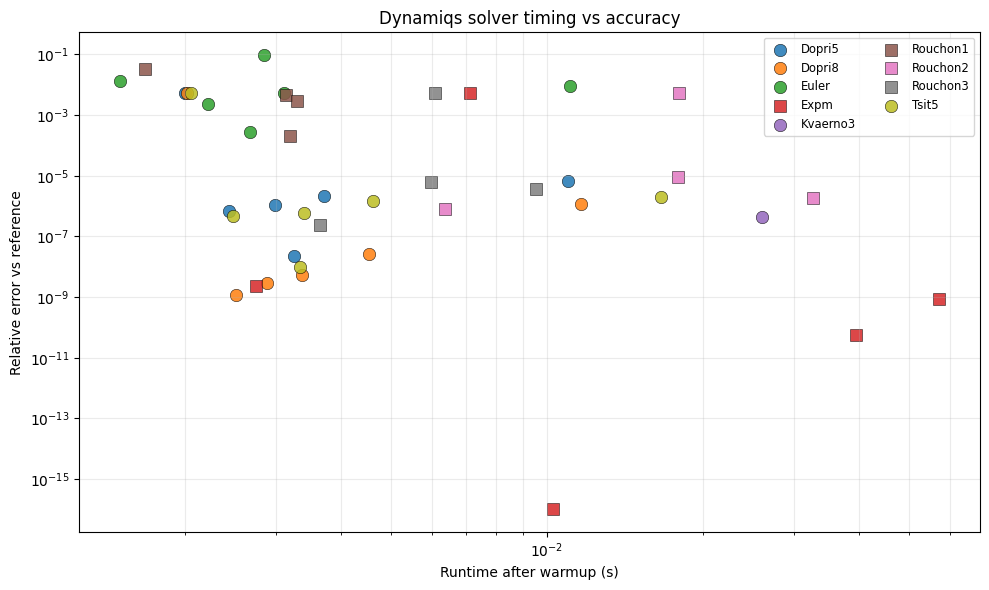

In [14]:
def scatter_accuracy_speed(rows, title='Dynamiqs solver timing vs accuracy'):
    fig, ax = plt.subplots(figsize=(10, 6))
    solvers = sorted({row['solver'] for row in rows})
    colors = {
        solver: plt.get_cmap('tab10')(idx % 10) for idx, solver in enumerate(solvers)
    }
    markers = {'sesolve': 'o', 'mesolve': 's'}

    for solver in solvers:
        group = [row for row in rows if row['solver'] == solver]
        ax.scatter(
            [row['runtime_s'] for row in group],
            [max(row['error'], 1e-16) for row in group],
            label=solver,
            color=colors[solver],
            marker=markers.get(group[0]['kind'], 'o'),
            alpha=0.85,
            s=80,
            edgecolor='black',
            linewidth=0.4,
        )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Runtime after warmup (s)')
    ax.set_ylabel('Relative error vs reference')
    ax.set_title(title)
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(ncols=2, fontsize='small')
    fig.tight_layout()
    return fig, ax


scatter_accuracy_speed(passed)
plt.show()

## Benchmark × solver heatmaps

These heatmaps make solver regressions easy to spot across runs. Darker runtime cells are slower; darker error cells are less accurate.

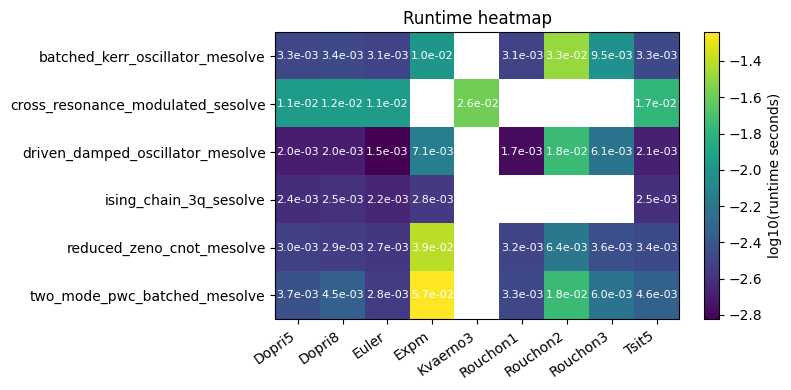

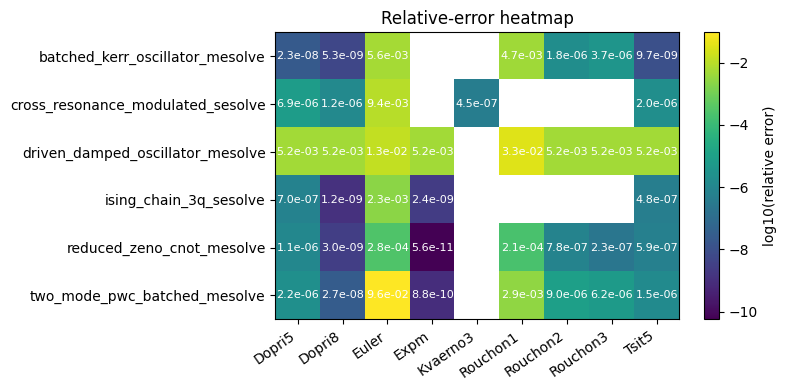

In [15]:
def pivot(rows, value_key):
    benchmarks = sorted({row['benchmark'] for row in rows})
    solvers = sorted({row['solver'] for row in rows})
    matrix = np.full((len(benchmarks), len(solvers)), np.nan)
    for row in rows:
        i = benchmarks.index(row['benchmark'])
        j = solvers.index(row['solver'])
        value = row[value_key]
        if not math.isnan(value):
            matrix[i, j] = value
    return benchmarks, solvers, matrix


def heatmap(rows, value_key, title, colorbar_label):
    benchmarks, solvers, matrix = pivot(rows, value_key)
    matrix = np.where(matrix > 0, matrix, np.nan)
    log_matrix = np.log10(matrix)

    fig, ax = plt.subplots(
        figsize=(max(8, len(solvers) * 0.7), max(4, len(benchmarks) * 0.45))
    )
    image = ax.imshow(log_matrix, aspect='auto', cmap='viridis')
    ax.set_xticks(np.arange(len(solvers)), labels=solvers, rotation=35, ha='right')
    ax.set_yticks(np.arange(len(benchmarks)), labels=benchmarks)
    ax.set_title(title)

    for i in range(len(benchmarks)):
        for j in range(len(solvers)):
            value = matrix[i, j]
            label = '—' if math.isnan(value) else f'{value:.1e}'
            ax.text(j, i, label, ha='center', va='center', color='white', fontsize=8)

    cbar = fig.colorbar(image, ax=ax)
    cbar.set_label(colorbar_label)
    fig.tight_layout()
    return fig, ax


heatmap(passed, 'runtime_s', 'Runtime heatmap', 'log10(runtime seconds)')
plt.show()

heatmap(passed, 'error', 'Relative-error heatmap', 'log10(relative error)')
plt.show()

## Per-benchmark Pareto frontiers

A solver is Pareto-efficient within a benchmark if no other passing solver is both faster and more accurate.

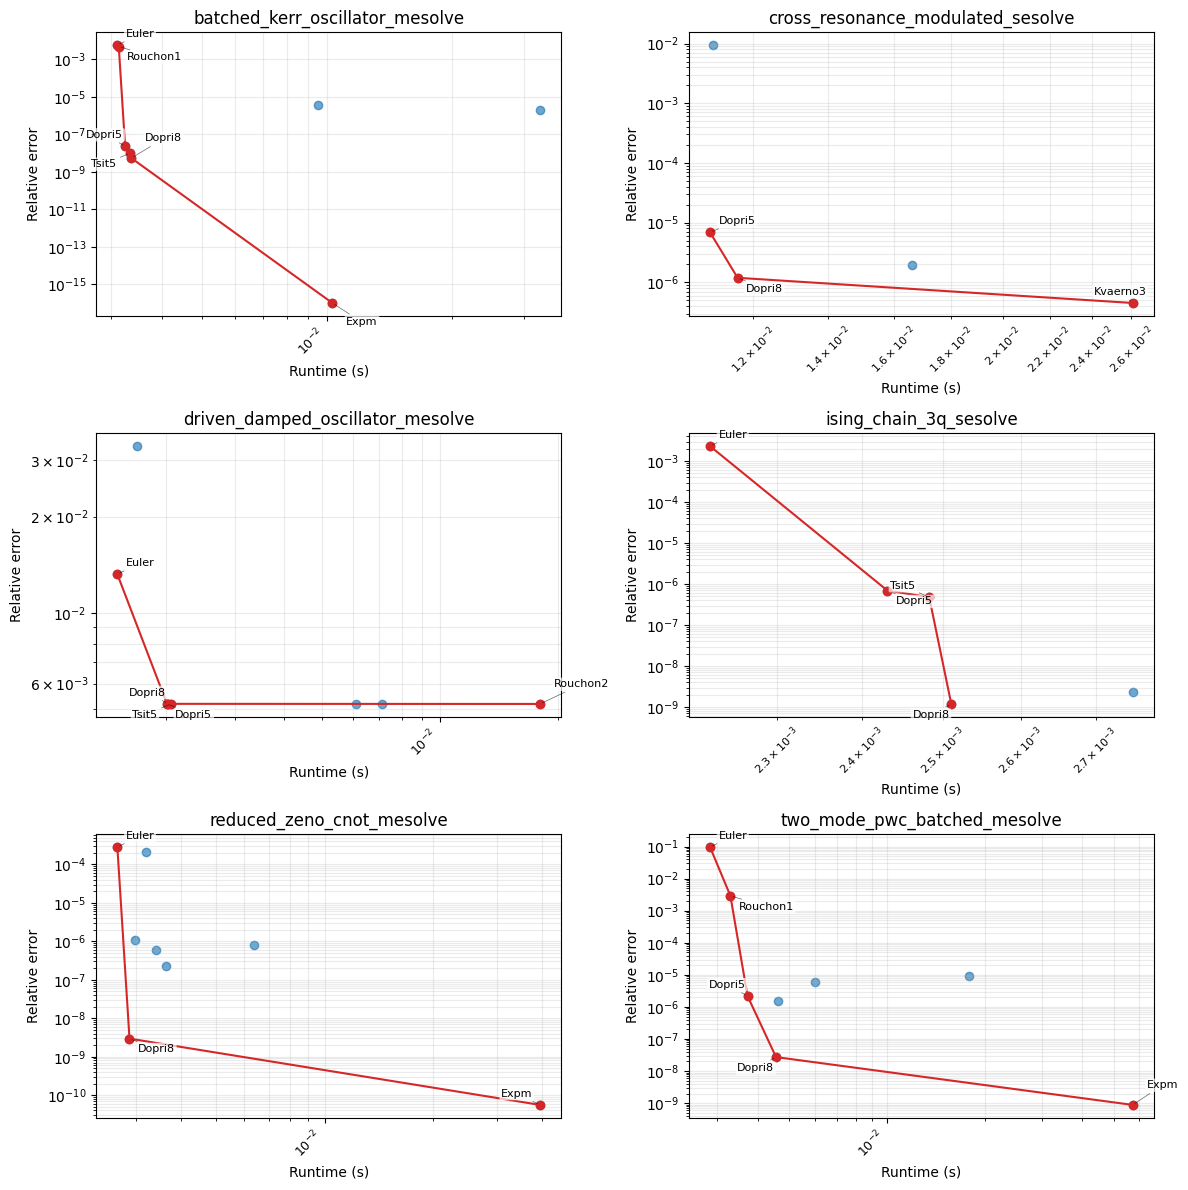

In [37]:
from matplotlib.ticker import LogLocator, NullFormatter

def pareto_front(group):
    ordered = sorted(group, key=lambda row: row['runtime_s'])
    frontier = []
    best_error = math.inf
    for row in ordered:
        if row['error'] < best_error:
            frontier.append(row)
            best_error = row['error']
    return frontier


benchmarks = sorted({row['benchmark'] for row in passed})
cols = 2
rows_needed = math.ceil(len(benchmarks) / cols)
fig, axes = plt.subplots(
    rows_needed, cols, figsize=(12, 4 * rows_needed), squeeze=False
)

for ax, benchmark in zip(axes.ravel(), benchmarks):
    group = [row for row in passed if row['benchmark'] == benchmark]
    frontier = pareto_front(group)
    ax.scatter(
        [row['runtime_s'] for row in group],
        [max(row['error'], 1e-16) for row in group],
        alpha=0.65,
    )
    ax.plot(
        [row['runtime_s'] for row in frontier],
        [max(row['error'], 1e-16) for row in frontier],
        color='tab:red',
        marker='o',
        label='Pareto frontier',
    )
    # for row in frontier:
    #     ax.annotate(
    #         row['solver'], (row['runtime_s'], max(row['error'], 1e-16)), fontsize=8
    #     )
    offsets = [(6, 6), (6, -10), (-28, 6), (-28, -10), (10, 12), (10, -16)]

    for i, row in enumerate(frontier):
        x = row['runtime_s']
        y = max(row['error'], 1e-16)
        dx, dy = offsets[i % len(offsets)]

        ax.annotate(
            row['solver'],
            xy=(x, y),
            xytext=(dx, dy),
            textcoords='offset points',
            fontsize=8,
            arrowprops=dict(arrowstyle='-', lw=0.5, alpha=0.6),
            bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.7, lw=0),
        )
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    # ax.set_title(benchmark)
    # ax.set_xlabel('Runtime (s)')
    # ax.set_ylabel('Relative error')
    # ax.grid(True, which='both', alpha=0.25)
    ax.set_xscale('log')
    ax.set_yscale('log')

    # ax.tick_params(axis='x', labelrotation=35)
    ax.tick_params(axis='x', which='major', labelsize=9, labelrotation=45)
    ax.tick_params(axis='x', which='minor', labelsize=8, labelrotation=45)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

    ax.set_title(benchmark)
    ax.set_xlabel('Runtime (s)')
    ax.set_ylabel('Relative error')
    ax.grid(True, which='both', alpha=0.25)

for ax in axes.ravel()[len(benchmarks) :]:
    ax.axis('off')

fig.tight_layout()
plt.show()

In [26]:
plot_paths = plot_results(RESULTS_CSV, OUTPUT_DIR / 'plots')
display(
    Markdown(
        'Saved static plot files:\n'
        + '\n'.join(f'- `{path.relative_to(REPO_ROOT)}`' for path in plot_paths)
    )
)

Saved static plot files:
- `benchmark_results/notebook_smoke/plots/timing_vs_accuracy.png`
- `benchmark_results/notebook_smoke/plots/runtime_by_solver.png`

## Solver failures and skips

Failures are part of the benchmark signal: they capture stability issues, tolerance problems, and unsupported method/problem combinations.
Skips document practical defaults. Explicit `--method` selections in the CLI can opt into slow implicit combinations.

In [25]:
diagnostic_rows = []
for row in failed + skipped:
    diagnostic_rows.append(
        [
            row['benchmark'],
            row['solver'],
            row['status'],
            row['message'][:160] + ('…' if len(row['message']) > 160 else ''),
        ]
    )

if diagnostic_rows:
    display(
        Markdown(
            markdown_table(
                ['Benchmark', 'Solver', 'Status', 'Message'], diagnostic_rows
            )
        )
    )
else:
    display(Markdown('No failed or skipped rows in this run.'))

| Benchmark | Solver | Status | Message |
| --- | --- | --- | --- |
| cross_resonance_modulated_sesolve | Kvaerno5 | fail | RuntimeError: An internal JAX error interrupted the execution, please report this to the Dynamiqs developers by opening an issue on GitHub or sending a message … |
| cross_resonance_modulated_sesolve | Rouchon1 | skip | unsupported solver/problem combination |
| cross_resonance_modulated_sesolve | Rouchon2 | skip | unsupported solver/problem combination |
| cross_resonance_modulated_sesolve | Rouchon3 | skip | unsupported solver/problem combination |
| cross_resonance_modulated_sesolve | Expm | skip | Expm only supports constant or piecewise-constant generators |
| driven_damped_oscillator_mesolve | Kvaerno3 | skip | implicit Kvaerno mesolve runs are opt-in because they can be very slow |
| driven_damped_oscillator_mesolve | Kvaerno5 | skip | implicit Kvaerno mesolve runs are opt-in because they can be very slow |
| batched_kerr_oscillator_mesolve | Kvaerno3 | skip | implicit Kvaerno mesolve runs are opt-in because they can be very slow |
| batched_kerr_oscillator_mesolve | Kvaerno5 | skip | implicit Kvaerno mesolve runs are opt-in because they can be very slow |
| ising_chain_3q_sesolve | Kvaerno3 | skip | implicit Kvaerno methods are not informative for this non-stiff scaling case |
| ising_chain_3q_sesolve | Kvaerno5 | skip | implicit Kvaerno methods are not informative for this non-stiff scaling case |
| ising_chain_3q_sesolve | Rouchon1 | skip | unsupported solver/problem combination |
| ising_chain_3q_sesolve | Rouchon2 | skip | unsupported solver/problem combination |
| ising_chain_3q_sesolve | Rouchon3 | skip | unsupported solver/problem combination |
| two_mode_pwc_batched_mesolve | Kvaerno3 | skip | implicit Kvaerno mesolve runs are opt-in because they can be very slow |
| two_mode_pwc_batched_mesolve | Kvaerno5 | skip | implicit Kvaerno mesolve runs are opt-in because they can be very slow |
| reduced_zeno_cnot_mesolve | Kvaerno3 | skip | implicit Kvaerno mesolve runs are opt-in because they can be very slow |
| reduced_zeno_cnot_mesolve | Kvaerno5 | skip | implicit Kvaerno mesolve runs are opt-in because they can be very slow |

## Tips for doing a deeper benchmarks based on existing methods

- Switch `PROFILE` to `standard` or `full` and keep the generated CSVs per commit.
- Compare two commits by loading both `results.csv` files and plotting ratios of runtime/error.
- Add memory measurements or gradient checks as secondary metrics once the primary deterministic suite is stable.